In [1]:
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
import glob
from tqdm import tqdm
from scipy.special import logsumexp
import os 
import pandas as pd
import h5py

import sys
sys.path.append('../../AMAZE_model_selection/')
from populations import bbh_models, gw_obs
import populations.bbh_models as read_models
from populations.bbh_models import read_hdf5
from sample import sample
from sample.sample import lnlike_cont
from sample.sample import lnpost


/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
params = ['mchirp','q', 'chieff', 'z']
chi_b = [0.0,0.1,0.2,0.5]
alpha = [0.2,0.5,1.,2.,5.]
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']
file_path='/data/wiay/2297403c/models_reduced.hdf5'
gw_path = "/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/GWTC-3/events_IMR"
np.random.seed(12)
observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            1000, 'posteriors', 'p_theta_jcb')
flow_path="/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/test_production_runs/flows_prod_tests/flow_models/"


model_names, flow = read_models.get_models(file_path, channels, params, use_flows=True, use_unityweights=False, device='cpu',\
     no_bins=[5,4,4,5,4], sensitivity='midhighlatelow', flow_path=flow_path)
for chnl in channels: flow[chnl].load_model(flow_path, device='cpu')

 80%|████████  | 4/5 [01:06<00:10, 10.64s/it]No printing after tqdm with condor?
cpu                                          
cpu
cpu
cpu
cpu


In [ ]:
model_samps, weights =flow['CE'].map_samples(flow['CE'].samples, flow['CE'].params, flow_path)


Mapping population synthesis samples for training...


(array([0.24702454, 0.44272652, 1.92077872, 3.74285946, 3.67881071,
        3.03123202, 2.76791446, 2.30624594, 1.48455252, 0.37785511]),
 array([1.        , 1.64189629, 2.28379257, 2.92568886, 3.56758514,
        4.20948143, 4.85137771, 5.493274  , 6.13517029, 6.77706657,
        7.41896286]),
 <BarContainer object of 10 artists>)

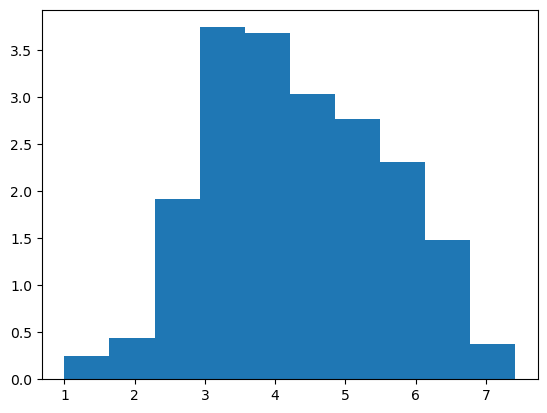

In [5]:
plt.hist(model_samps[:,0], weights=weights)

In [3]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}

like=[]
for alpha_CE_idx in np.linspace(0,4,100):
    x = [1.0,alpha_CE_idx,0.8,0.05,0.05,0.01,0.02]
    like.append(lnlike_disc(x, obsdata, flow, submodels_dict, channels, p_theta, True, smallest_N=990903))

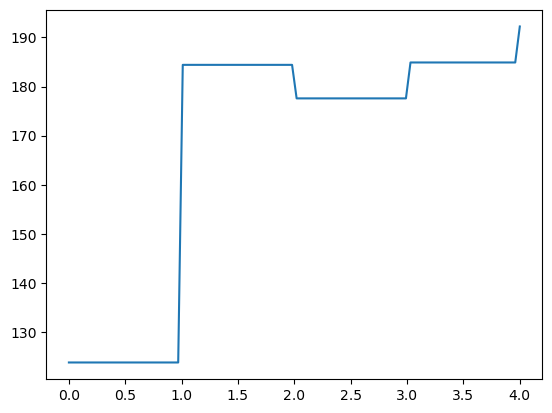

In [5]:
plt.plot(np.linspace(0,4,100), like)

#profiling sampling

In [13]:
import cProfile
import numpy as np

x = [0.1,0.9,0.5,0.1,0.2,0.02]
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
_concentration = [1.,1.,1.,1.,1.]
use_flows=True
smallest_N=100000
hyperparam_bounds = [[0,0.5],[0.,5.]]

def time_func():

    for i in range(100):
        x = [np.random.rand(1)*0.5,0.9,0.5,0.1,0.2,0.02]
        lnpost(x, obsdata, flow, submodels_dict, channels, use_flows, smallest_N, p_theta, hyperparam_bounds, discrete_sample=False)

cProfile.run('time_func()',\
    sort='cumtime')

         4 function calls in 0.000 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.000    0.000 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 450713454.py:11(time_func)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}




TypeError: lnpost() missing 1 required positional argument: 'hyperparam_bounds'

OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).


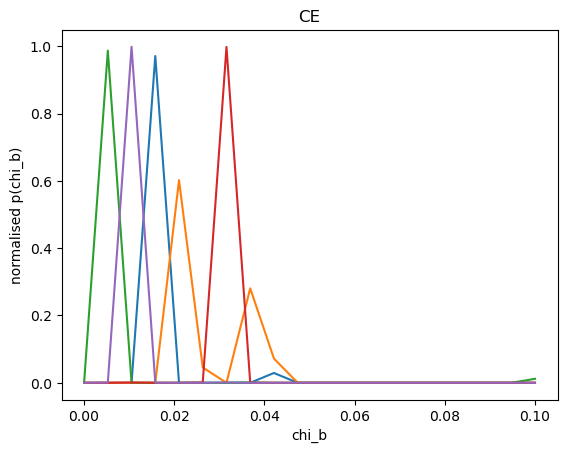

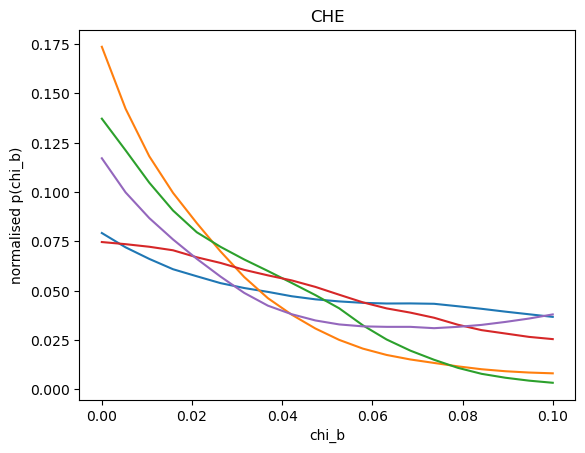

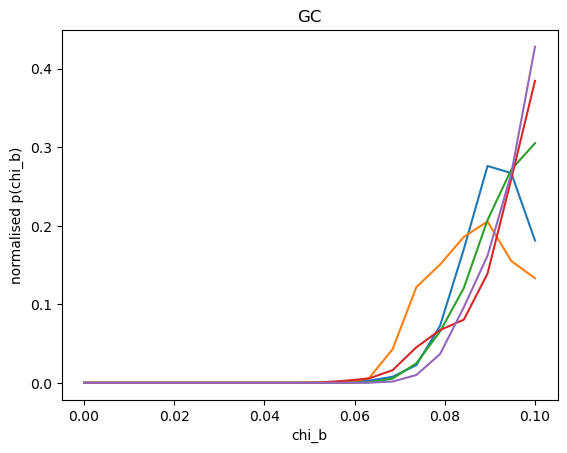

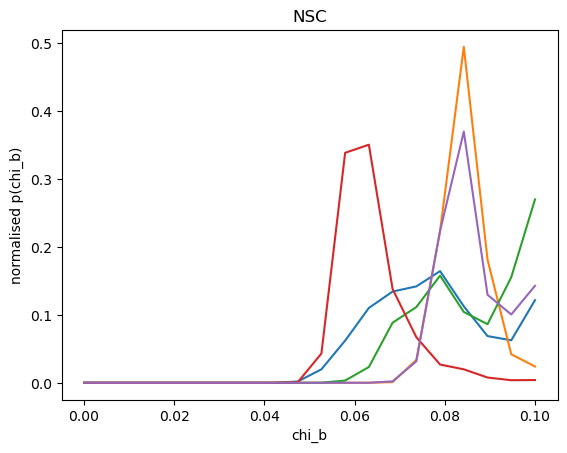

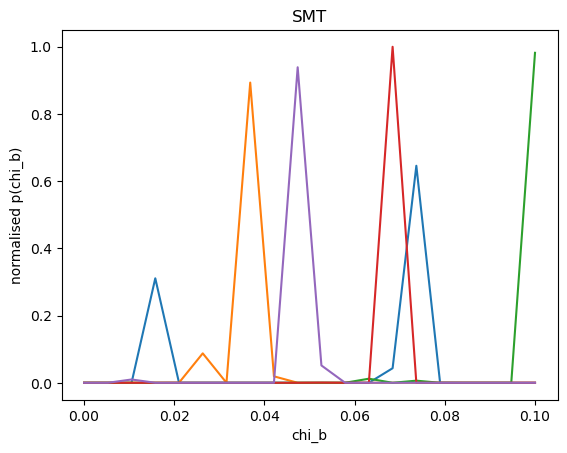

In [3]:
x = [0.1,0.9,0.5,0.1,0.2,0.02]
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
_concentration = [1.,1.,1.,1.,1.]
use_flows=True
smallest_N=100000
hyperparam_bounds = [[0.,0.5],[0.,5.]]

prob = np.zeros((10,20))
for chnl in channels:
    for seed in range(5):
        np.random.seed(12)
        observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                                100, 'posteriors', 'p_theta_jcb')

        np.random.seed(seed)
        obsdata +=0.1*(np.random.rand(np.shape(obsdata[:,:,:])[0],np.shape(obsdata[:,:,:])[1],np.shape(obsdata[:,:,:])[2],)-0.5)
        #plt.hist(obsdata[0,:,2], bins=20, alpha=0.5)
        obsdata[obsdata[:,:,2]>0.99] = 0.99
        obsdata[obsdata[:,:,1]>0.99] = 0.99
        obsdata[obsdata[:,:,1]<0.001] = 0.001
        obsdata[obsdata[:,:,3]<0.001] = 0.001
        for i, chib in enumerate(np.linspace(0,0.1,20)):
            x = [chib,4.8,0.8,0.05,0.01,0.05]
            prob[seed,i] = (lnlike_cont(x, obsdata, flow, submodels_dict, [chnl], None, smallest_N))
        plt.plot(np.linspace(0,0.1,20), np.exp(prob[seed,:])/np.sum(np.exp(prob[seed,:])))
    plt.xlabel('chi_b')
    plt.ylabel('normalised p(chi_b)')
    plt.title(chnl)
    plt.show()


In [5]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000


prob = np.zeros((20,5))
for seed in range(5):
    np.random.seed(seed)
    observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            1993, 'posteriors', 'p_theta_jcb')
    #for e, event in enumerate(obsdata):
    for i, chib in enumerate(tqdm(np.linspace(0,0.1,20))):
        x = [chib,4.8,0.8,0.05,0.01,0.05]
        prob[i,seed] = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, None, smallest_N))
"""
for e, event in enumerate(obsdata):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed,e])/np.sum(np.exp(prob[:,seed,e])))
    plt.xlabel('chi_b')
    plt.ylabel('normalised p(chi_b)')
    plt.show()"""

  0%|          | 0/20 [00:00<?, ?it/s]OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).
100%|██████████| 20/20 [02:16<00:00,  6.82s/it]


"\nfor e, event in enumerate(obsdata):\n    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed,e])/np.sum(np.exp(prob[:,seed,e])))\n    plt.xlabel('chi_b')\n    plt.ylabel('normalised p(chi_b)')\n    plt.show()"

Text(0, 0.5, 'normalised p(chi_b)')

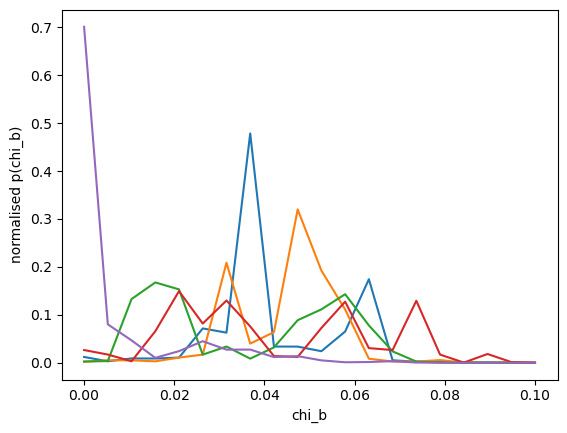

In [6]:
for seed in range(5):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('chi_b')
plt.ylabel('normalised p(chi_b)')

Text(0, 0.5, 'normalised p(chi_b)')

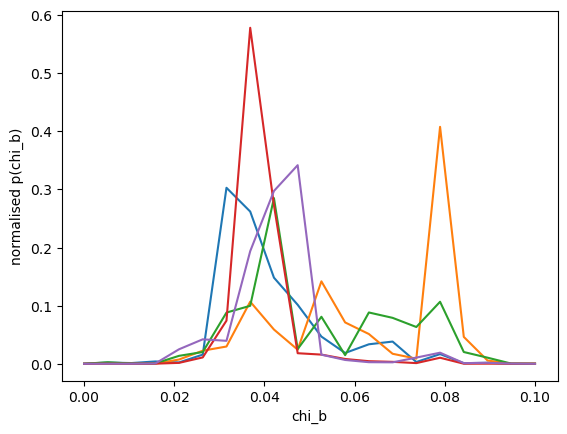

In [5]:
for seed in range(5):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('chi_b')
plt.ylabel('normalised p(chi_b)')

Text(0, 0.5, 'normalised p(chi_b)')

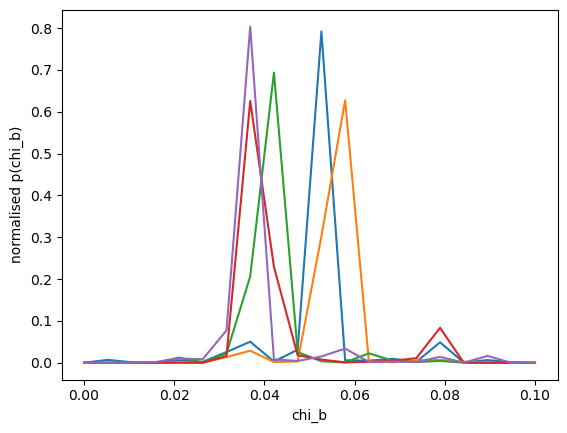

In [6]:
for seed in range(5):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('chi_b')
plt.ylabel('normalised p(chi_b)')

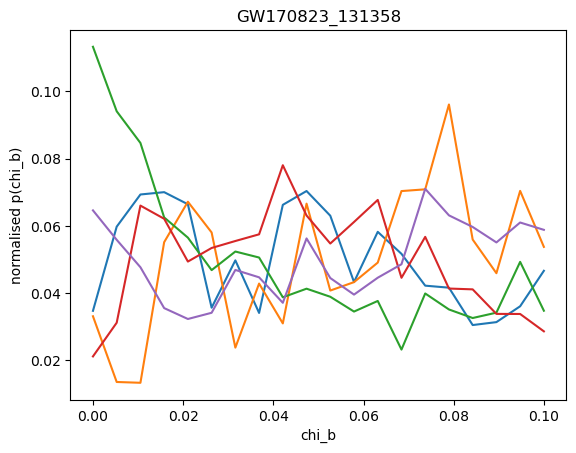

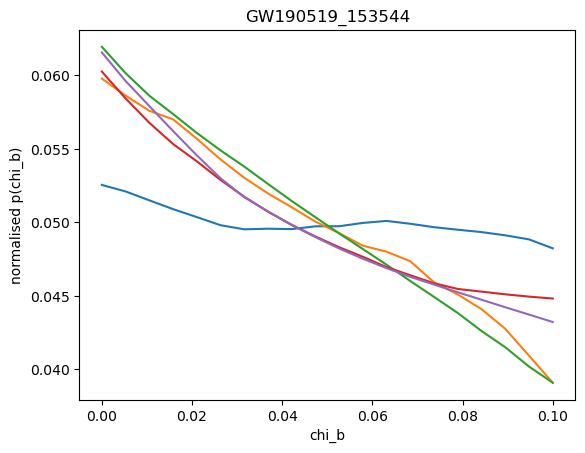

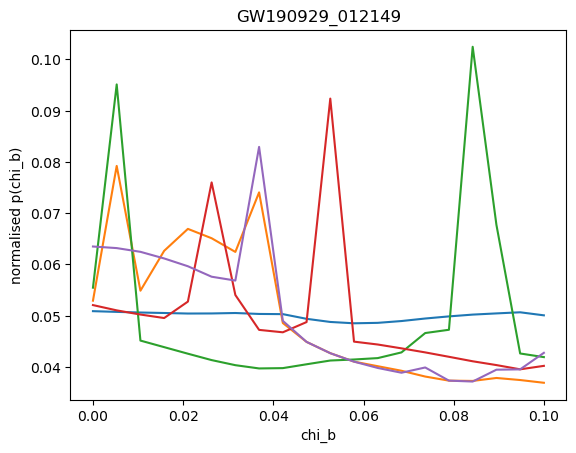

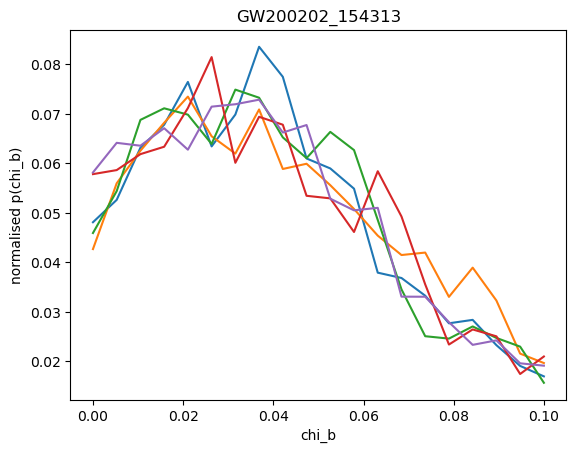

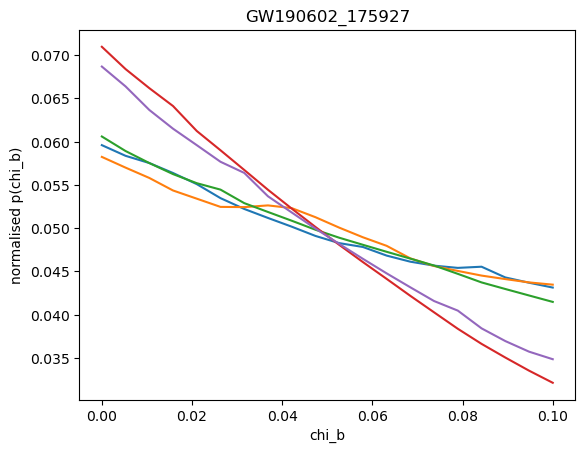

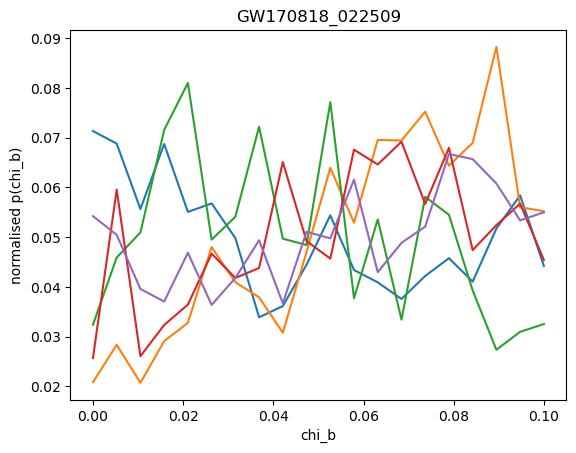

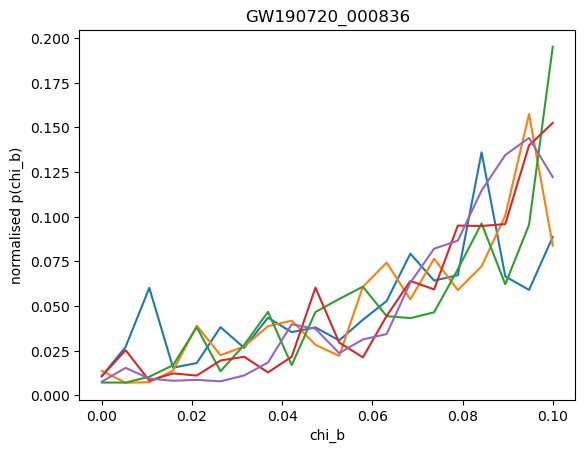

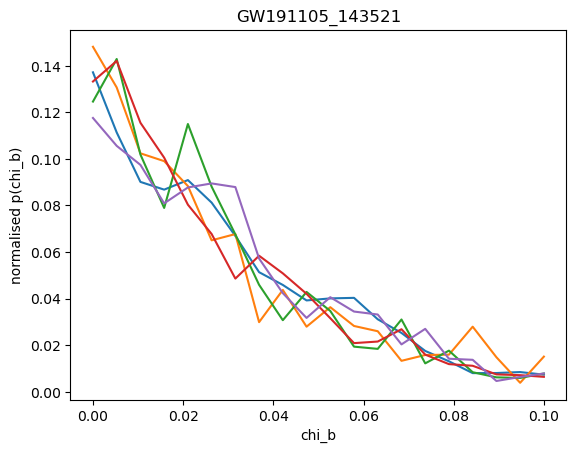

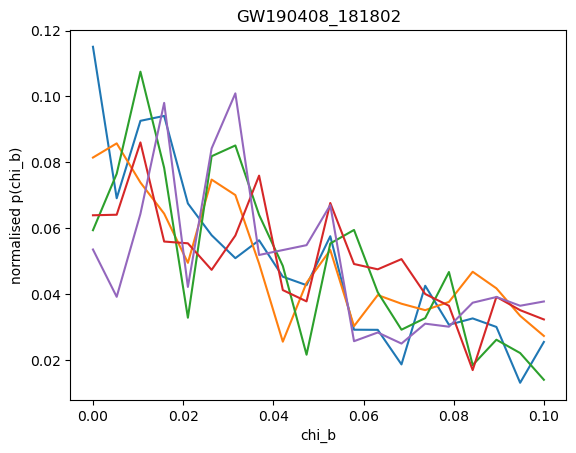

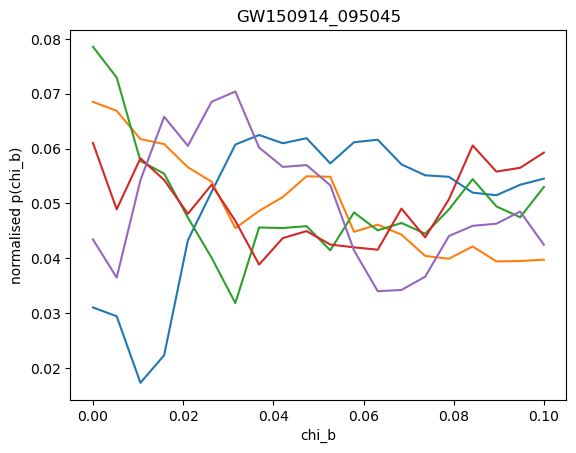

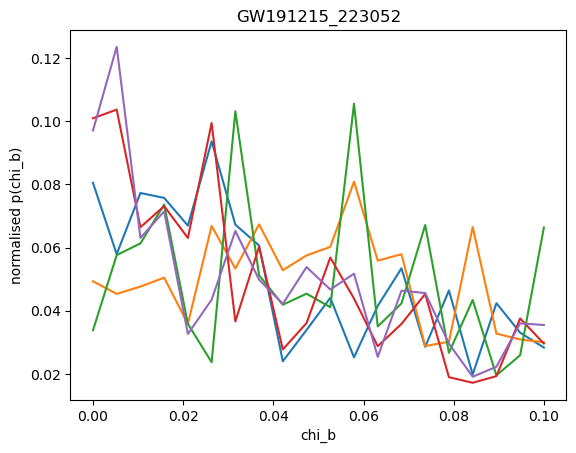

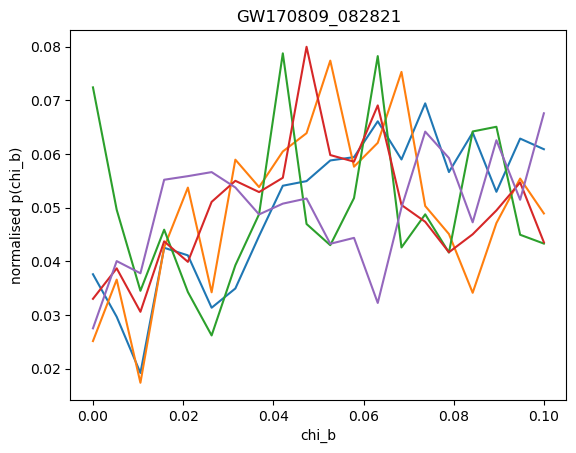

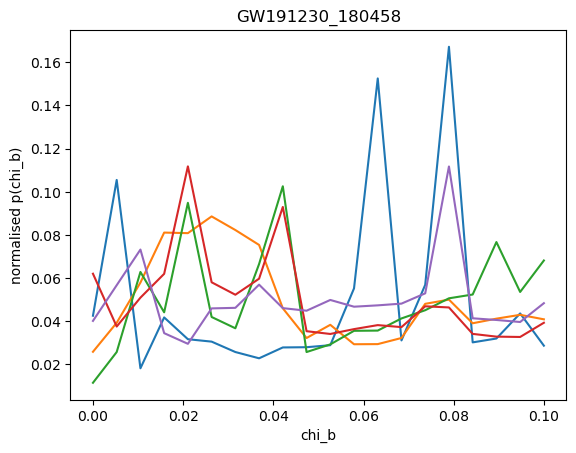

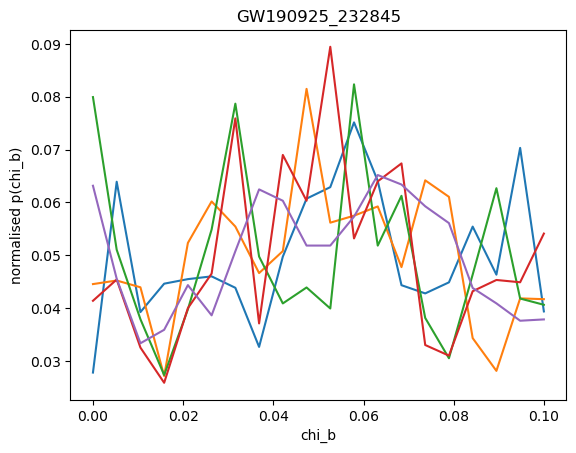

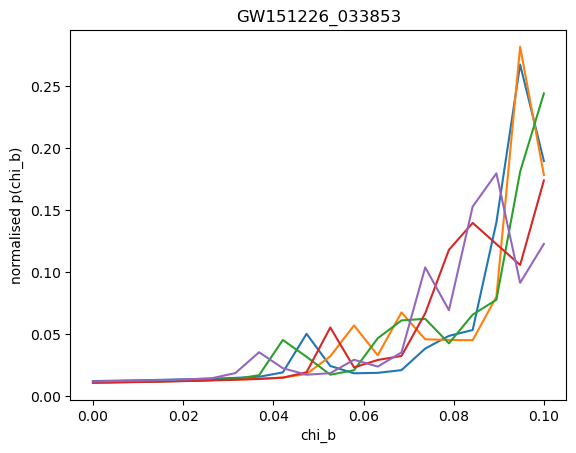

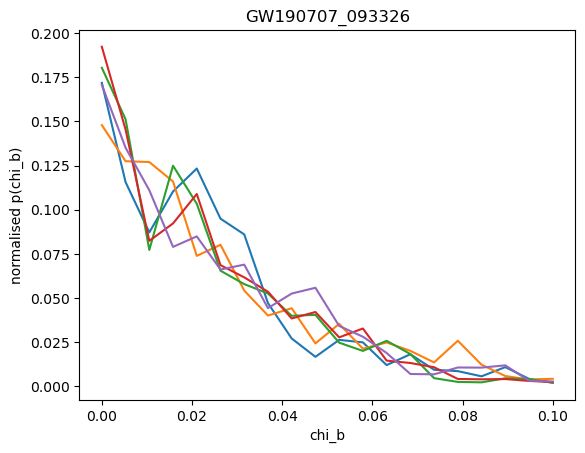

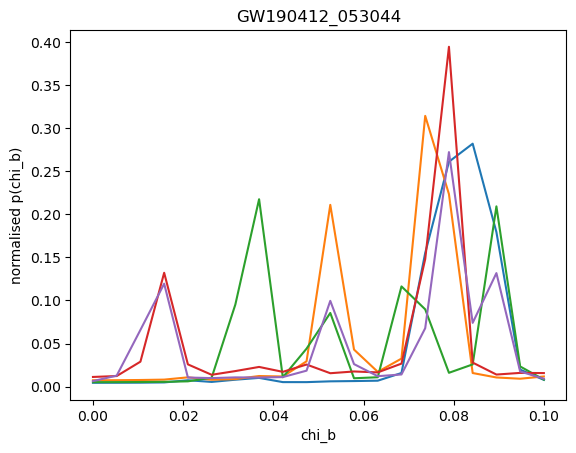

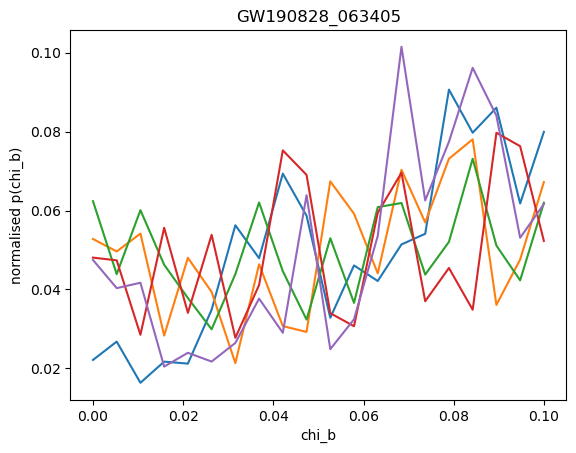

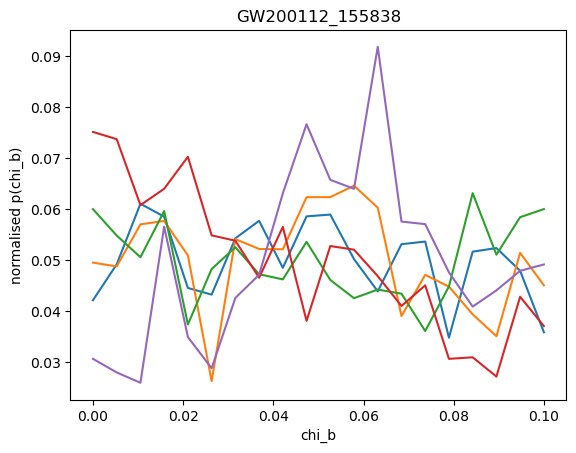

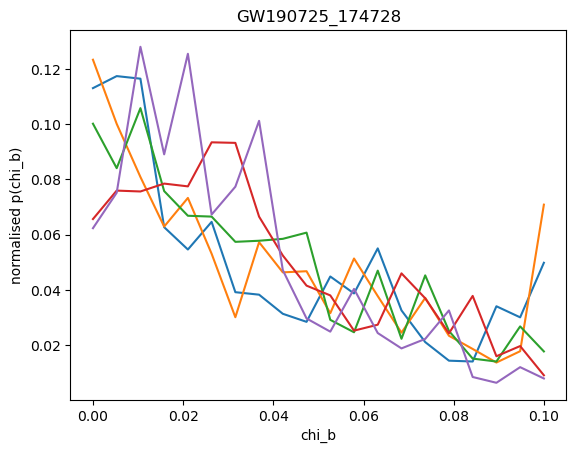

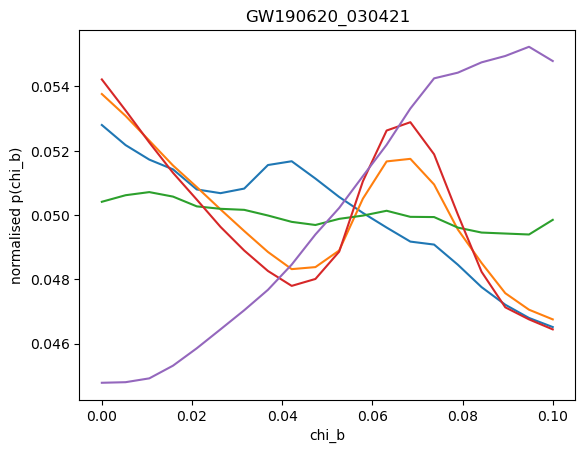

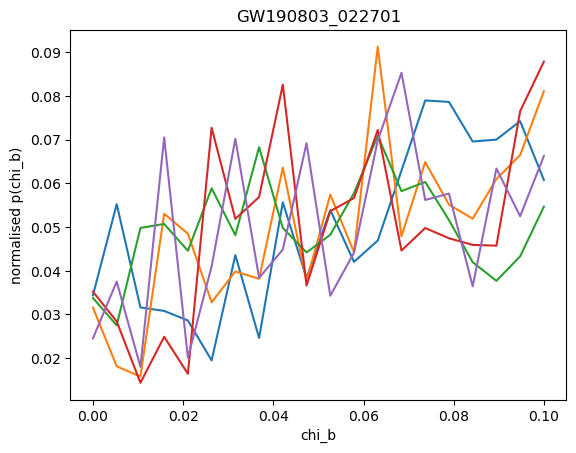

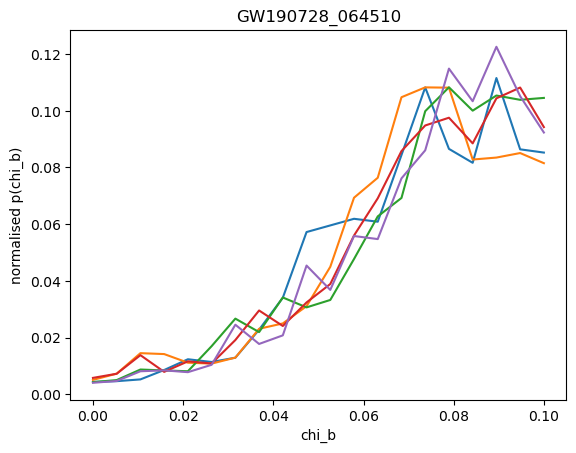

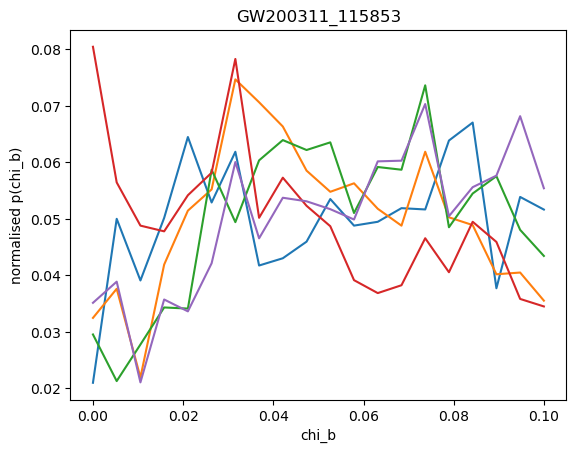

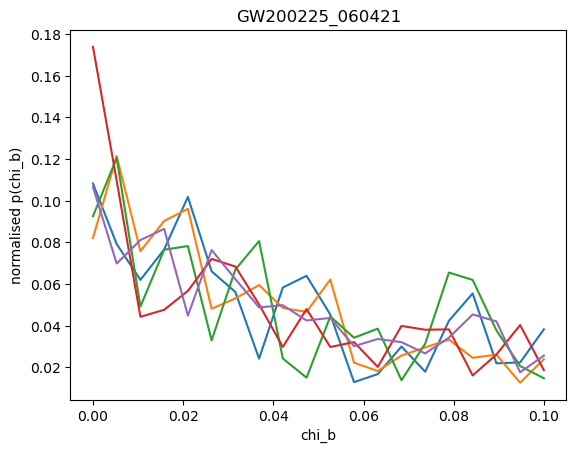

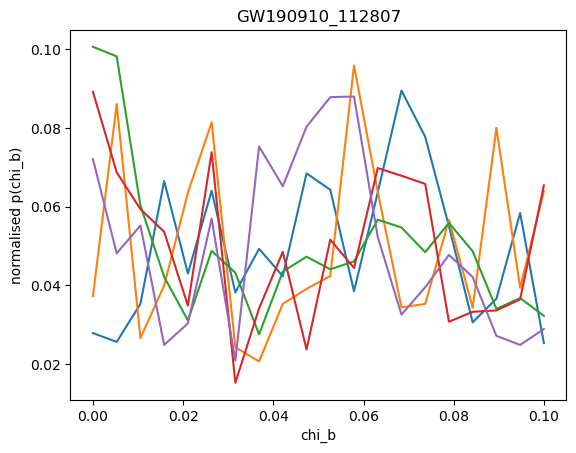

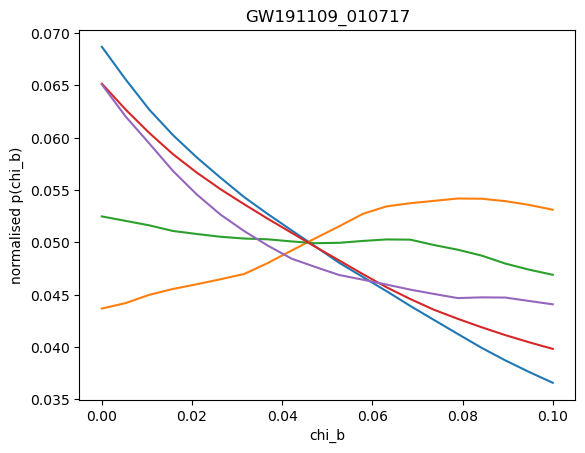

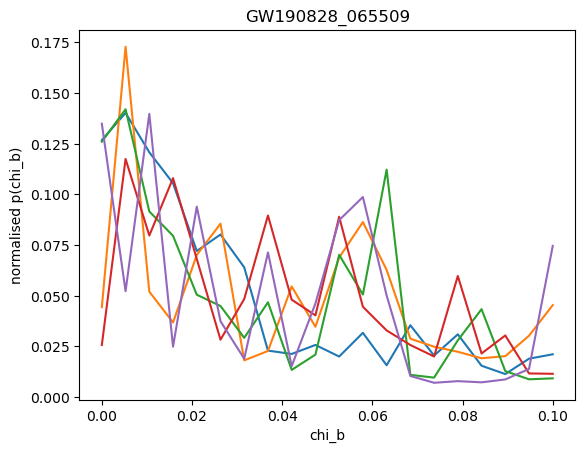

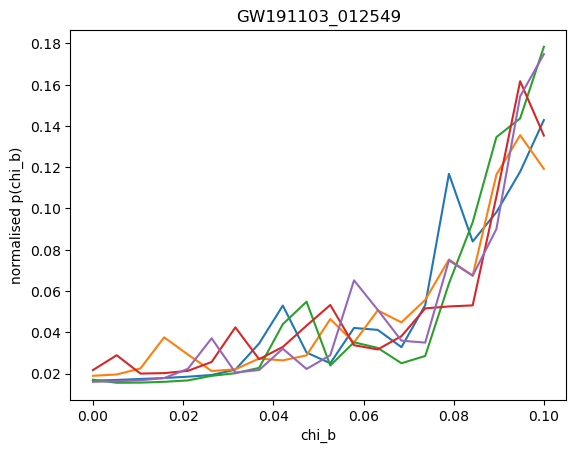

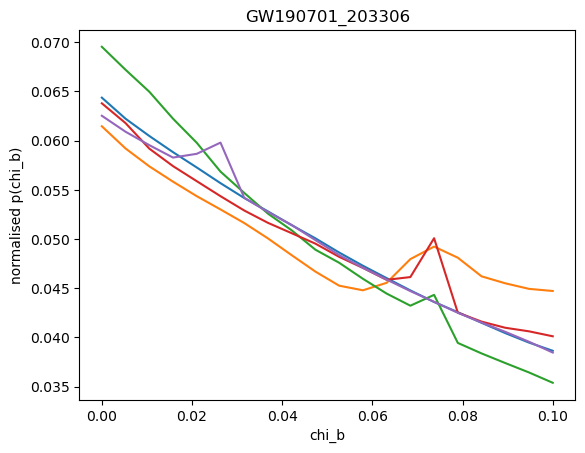

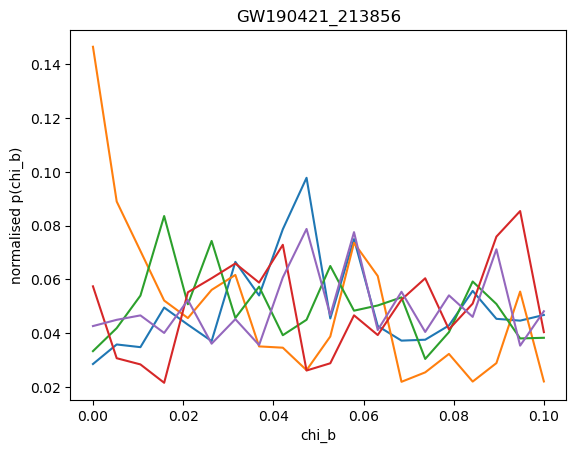

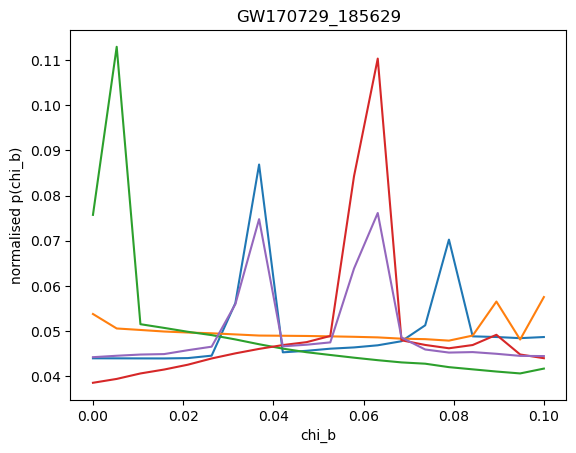

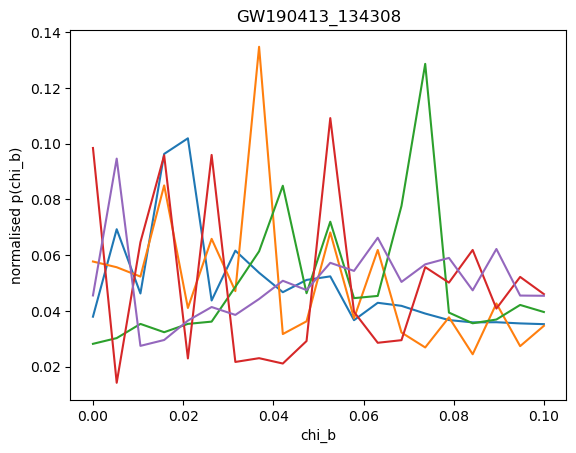

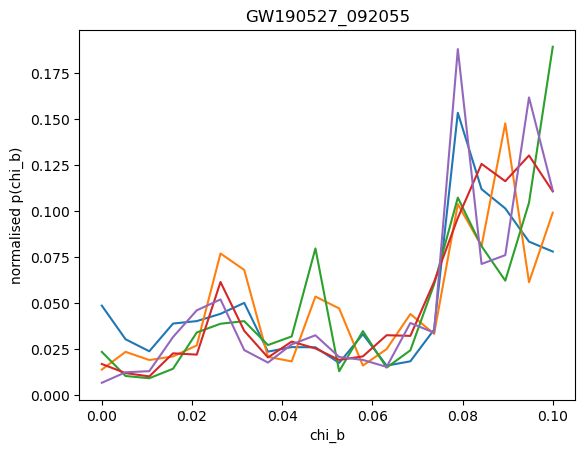

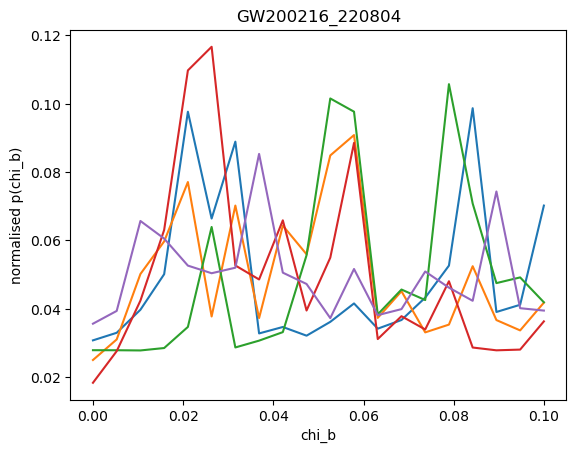

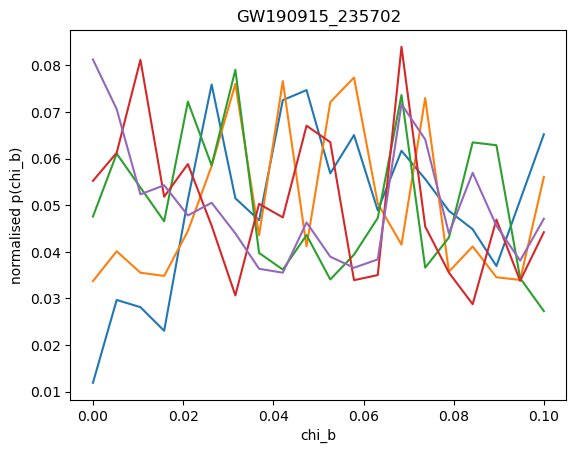

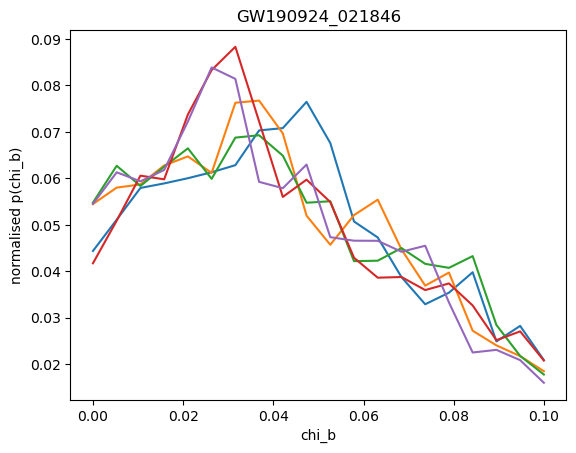

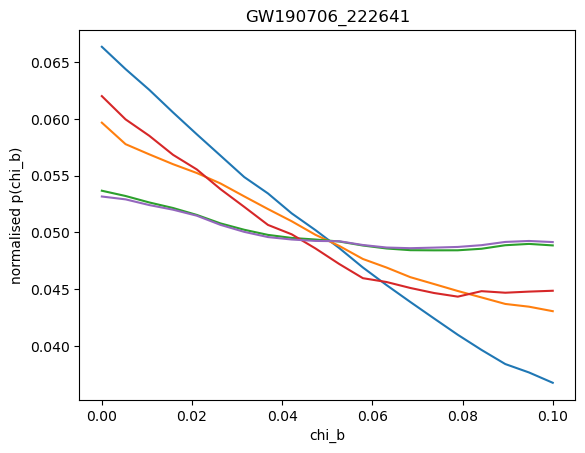

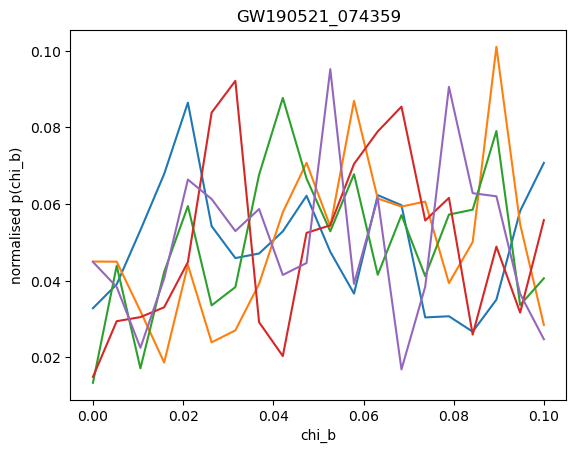

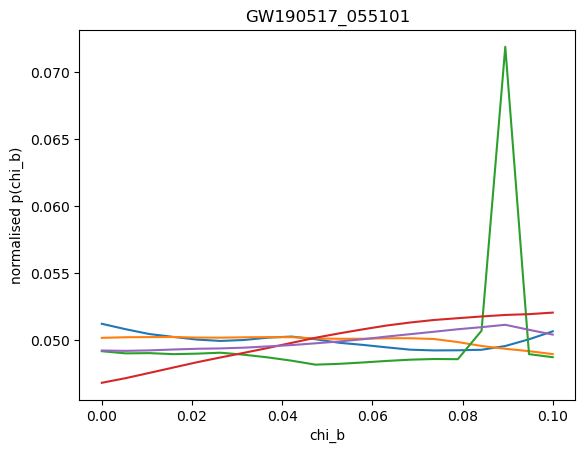

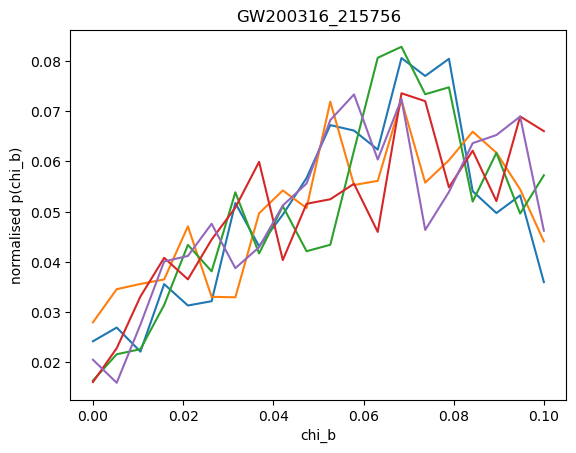

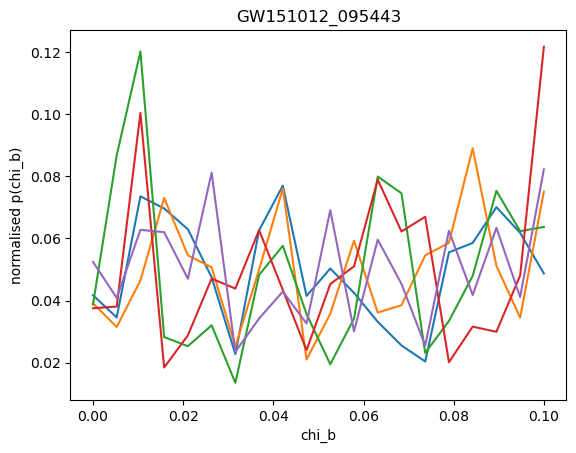

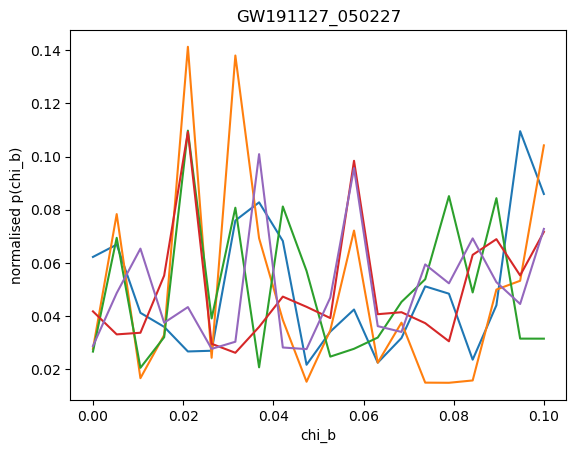

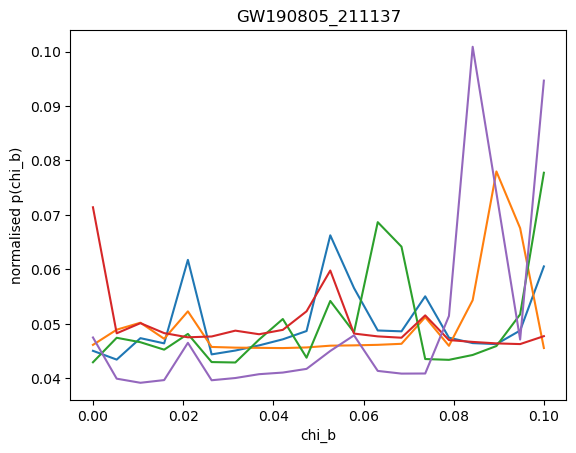

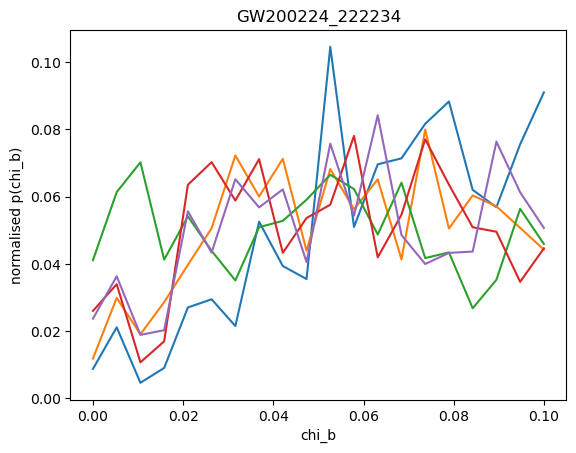

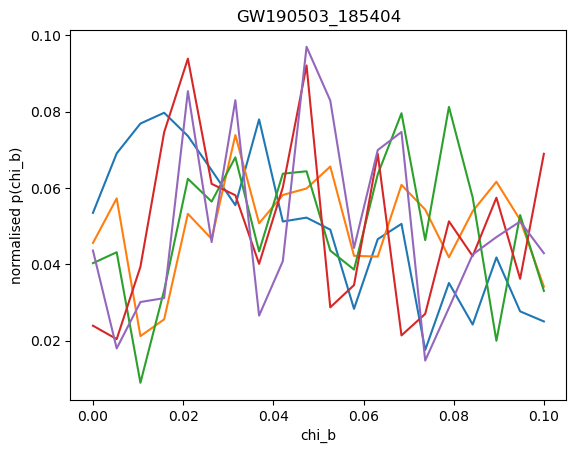

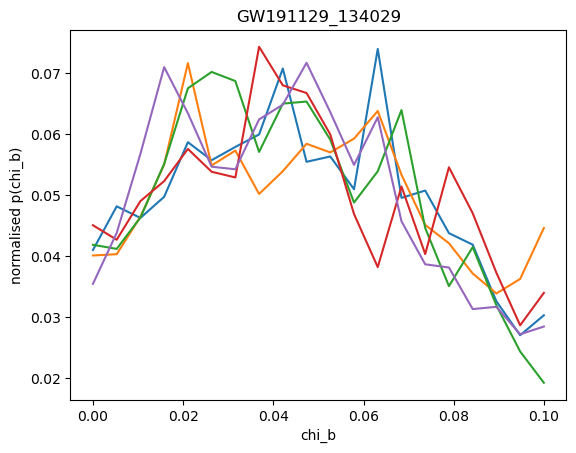

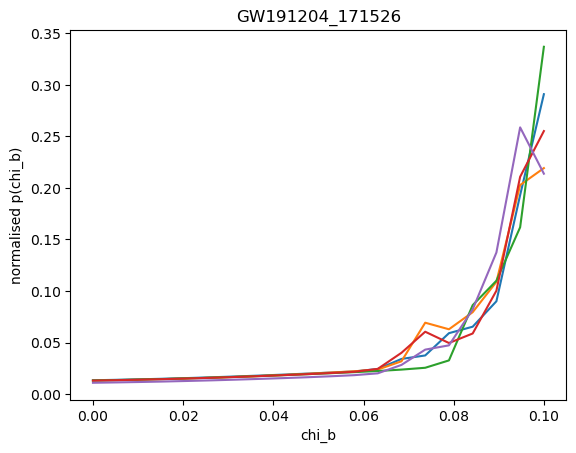

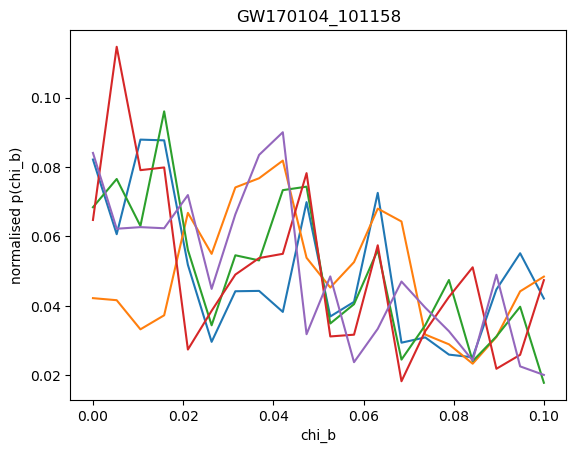

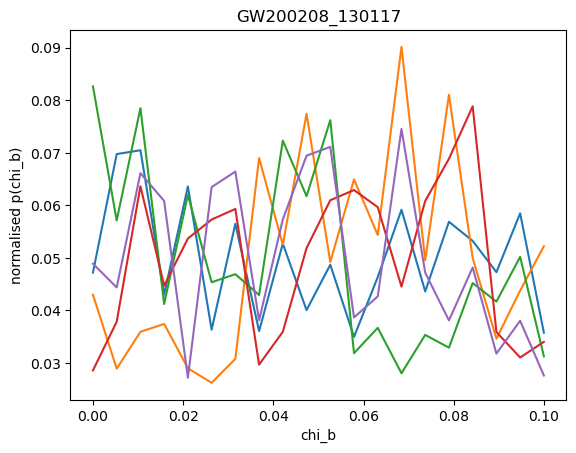

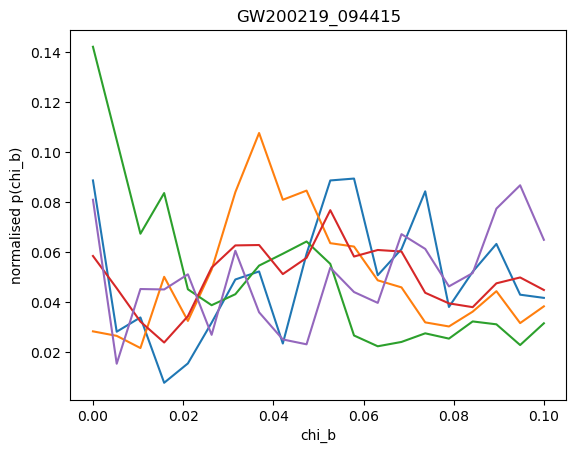

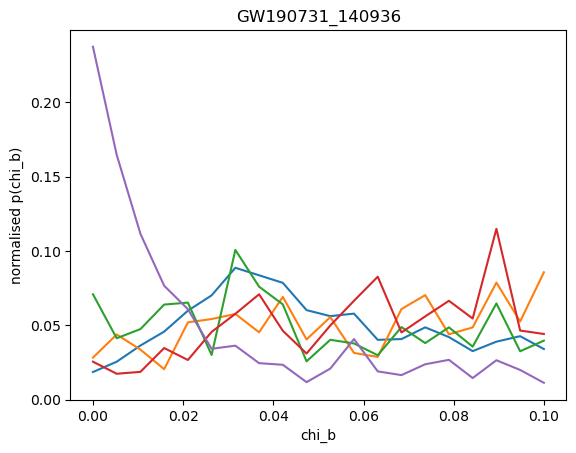

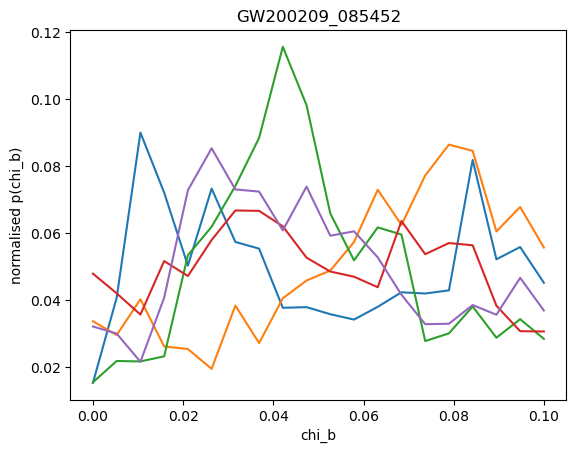

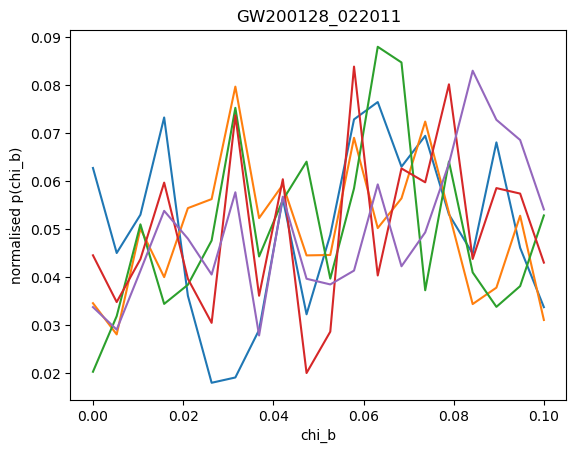

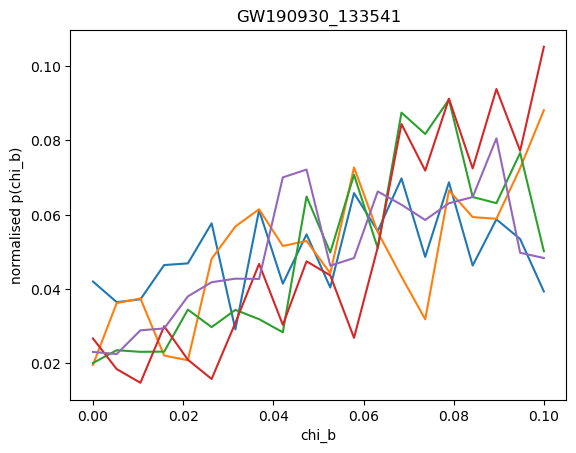

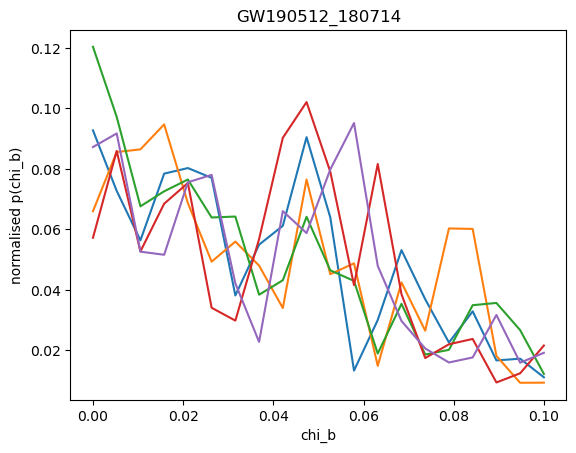

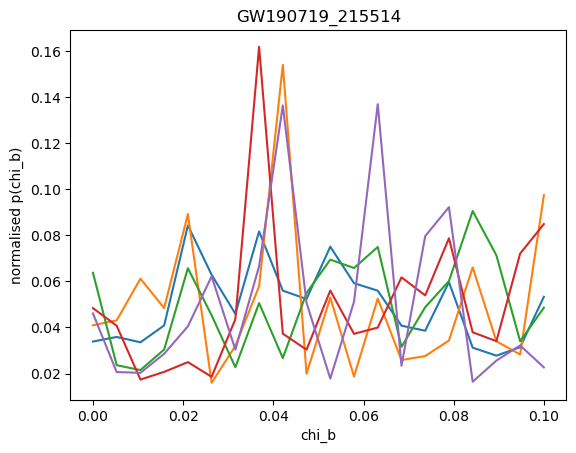

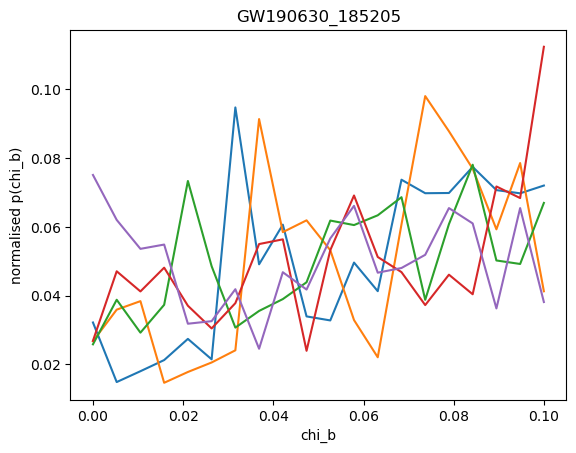

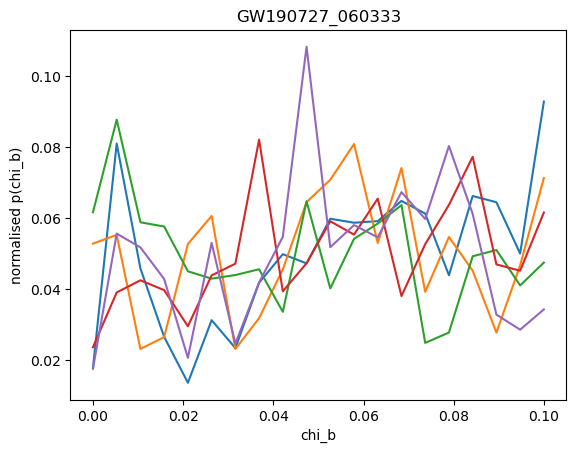

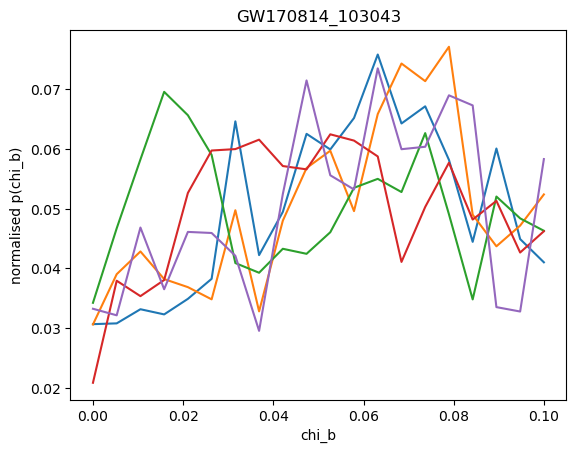

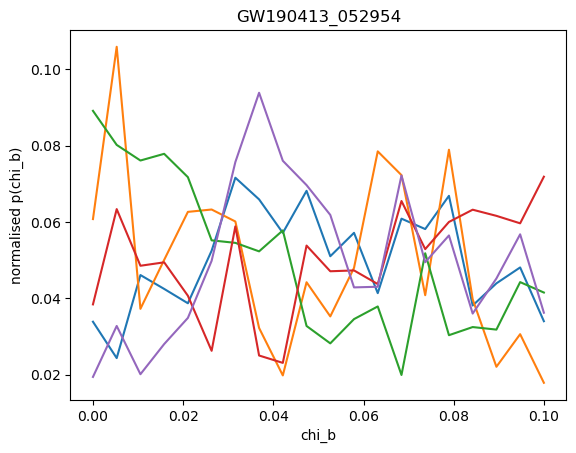

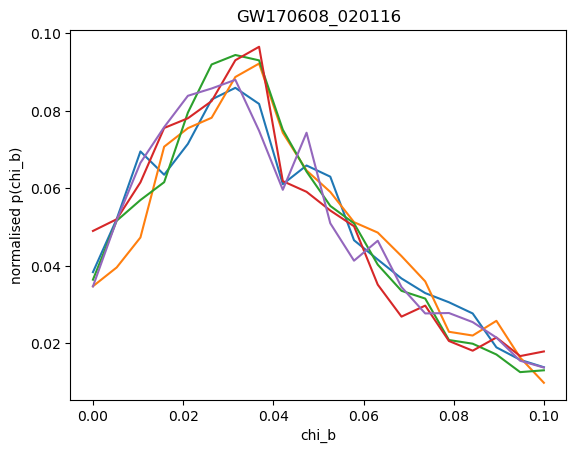

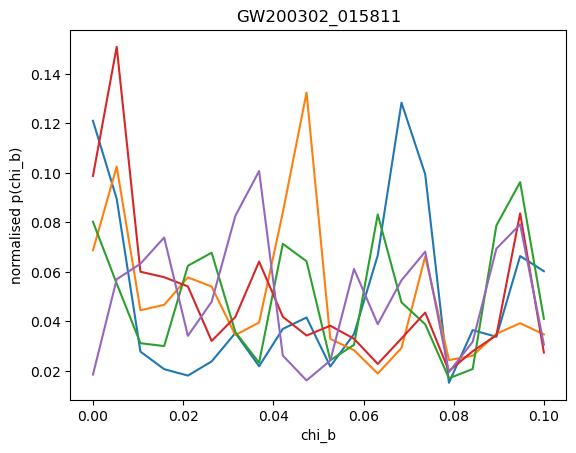

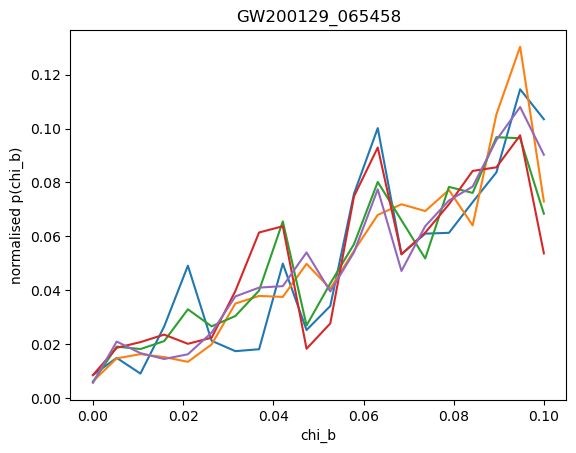

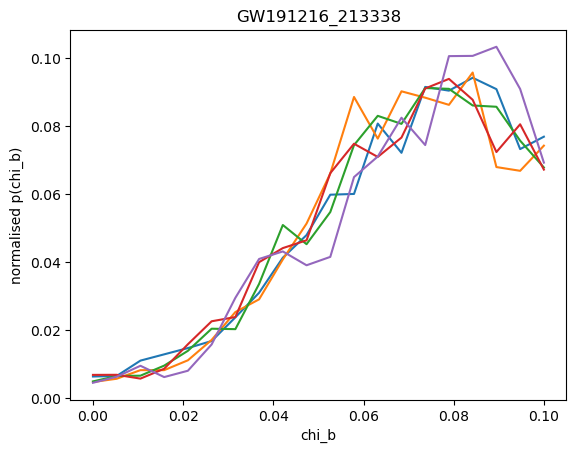

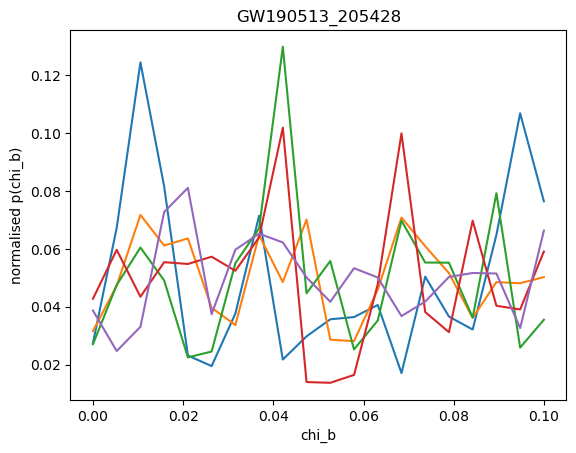

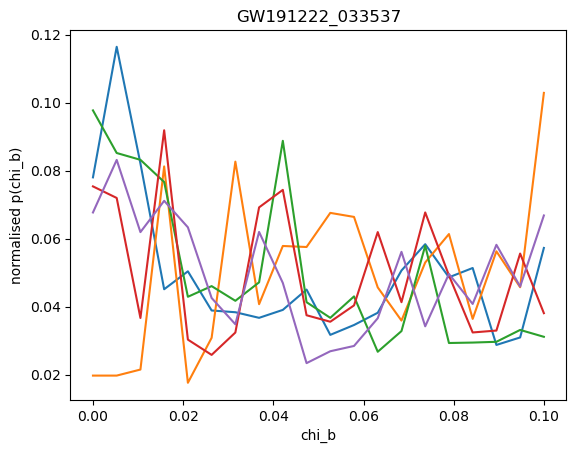

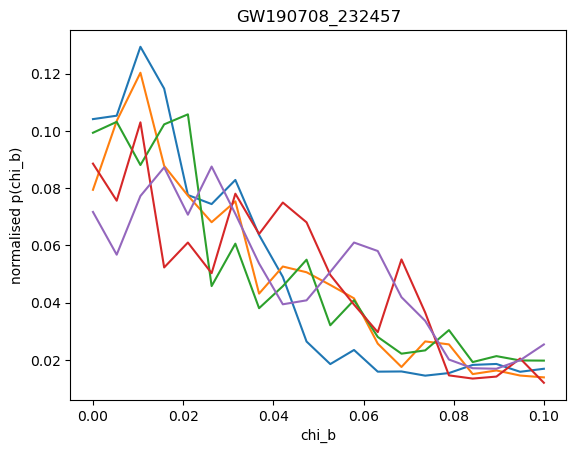

In [15]:
for e, event in enumerate(obsdata):
    for seed in range(5):
        plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed,e])/np.sum(np.exp(prob[:,seed,e])))
    plt.title(events[e])
    plt.xlabel('chi_b')
    plt.ylabel('normalised p(chi_b)')
    plt.show()

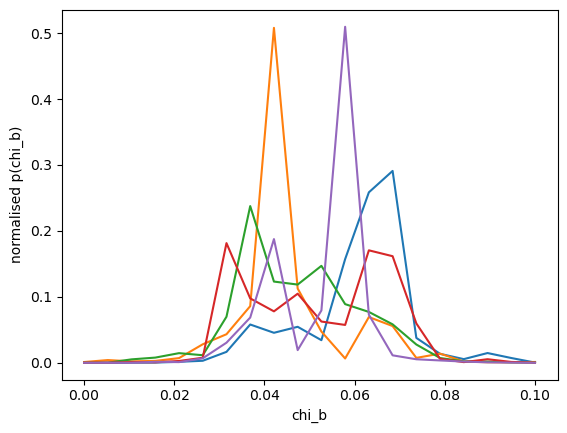

In [3]:
prob = np.load('allpstsamps_probs_IMR.npy')
for seed in range(5):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[seed,:])/np.sum(np.exp(prob[seed,:])))
#plt.title(events[e])
plt.xlabel('chi_b')
plt.ylabel('normalised p(chi_b)')
plt.show()

In [13]:
#check max no of posterior samples
post_samps = []
for data_file in glob.glob(gw_path+'/*.hdf5'):
    f = h5py.File(data_file)
    post_samps.append(f['combined']['block0_values'].shape[0])
print(np.max(post_samps))
np.min(post_samps)

249520


6913

In [10]:
len(np.array(post_samps)[np.array(post_samps)<10000])

0

In [11]:
np.array(post_samps)[np.array(post_samps)<10000]

array([], dtype=int64)

Text(0.5, 0, 'No. event posterior samples')

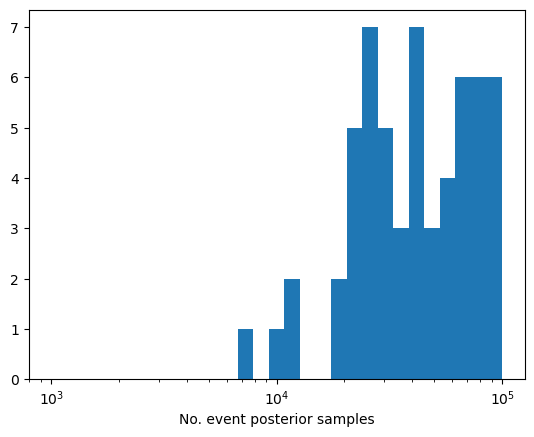

In [14]:
plt.hist(post_samps, bins =np.logspace(np.log10(1000),np.log10(100000), 30))
plt.xscale('log')
plt.xlabel('No. event posterior samples')

In [15]:
np.random.rand(np.shape(obsdata[:,:,:])[0],np.shape(obsdata[:,:,:])[1],np.shape(obsdata[:,:,:])[2],)

array([[[0.06818027, 0.23028506, 0.64226059, 0.19880316],
        [0.53717793, 0.16586076, 0.67270551, 0.53123612],
        [0.96943224, 0.13381328, 0.53072125, 0.31172389],
        ...,
        [0.07167158, 0.61238183, 0.07805252, 0.47189499],
        [0.61451276, 0.93910267, 0.9212722 , 0.60745745],
        [0.50271252, 0.65039118, 0.92496549, 0.99094042]],

       [[0.03309033, 0.96955209, 0.80318598, 0.07500484],
        [0.80016788, 0.66263291, 0.90573794, 0.45779728],
        [0.50333846, 0.83731331, 0.48378779, 0.5263679 ],
        ...,
        [0.02816361, 0.75923623, 0.0739897 , 0.64015902],
        [0.53753145, 0.51849055, 0.29968502, 0.75602864],
        [0.40061355, 0.15125457, 0.05604314, 0.342548  ]],

       [[0.60805498, 0.22032209, 0.74220479, 0.10872581],
        [0.47196476, 0.53670425, 0.8210121 , 0.11794768],
        [0.00167499, 0.53370971, 0.15072507, 0.57169337],
        ...,
        [0.92605314, 0.43534478, 0.55064498, 0.18911779],
        [0.69343226, 0.212707

[-94.35052142 -88.19904631 -88.18536809 -76.85026482 -79.83661489
 -80.54041448 -78.51781232 -90.04232244 -85.36792498 -71.15415564
 -71.93984108 -70.70219286 -72.93811073 -82.06762124 -86.65507552
 -77.76402631 -75.51669798 -83.9785307  -86.39552039 -93.71928696]
[-92.82386035 -95.76483107 -95.70109369 -88.18697181 -85.80143201
 -91.55759601 -94.19548966 -89.8016724  -86.94725433 -77.74049207
 -74.41244648 -80.35979325 -82.15643798 -80.9661479  -89.9541825
 -85.03299518 -80.89330464 -83.97015892 -84.44255227 -93.67865115]
[ -96.20902802  -94.04930669  -90.02908605  -82.81658408  -82.74703234
  -85.27175343  -89.48535805  -91.90038325  -89.71751715  -79.90185496
  -80.21859024  -86.44609359  -85.40199621  -89.64706657  -92.26016898
  -81.1708855   -83.22664217  -89.83987081  -91.5834006  -102.40908892]
[-107.2808876  -102.97816251  -99.71612998  -91.57197403  -90.11083102
  -94.08789206  -97.64215728  -99.07394594  -96.24792625  -86.9646248
  -88.04821829  -93.12924871  -90.71275662  -

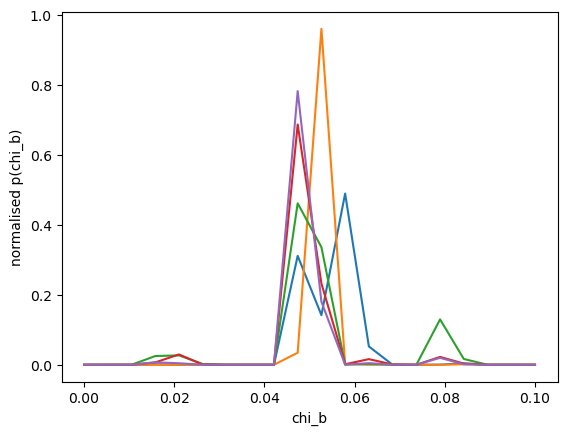

In [16]:
for seed in range(5):
    print(prob[seed,:])
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[seed,:])/np.sum(np.exp(prob[seed,:])))
    plt.xlabel('chi_b')
    plt.ylabel('normalised p(chi_b)')

In [13]:
prob_10000Nsamps = np.zeros((10,30))
for seed in range(5):
    np.random.seed(seed)
    observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            10000, 'posteriors', 'p_theta_jcb')
    for i, chib in enumerate(np.linspace(0,0.1,20)):
        x = [chib,4.8,0.8,0.05,0.01,0.05]
        prob_10000Nsamps[seed,i] = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

[0.0, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.005263157894736842, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.010526315789473684, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.015789473684210527, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.021052631578947368, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.02631578947368421, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.031578947368421054, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.03684210526315789, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.042105263157894736, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.04736842105263158, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.05263157894736842, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.05789473684210526, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.06315789473684211, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.06842105263157895, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.07368421052631578, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.07894736842105263, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.08421052631578947, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.08947368421052632, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.09473684210526316, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.1, 4.8, 0.8, 0.05, 0.01, 0.05]
[0.0, 4.8, 0.8, 0.05, 0.01

KeyboardInterrupt: 

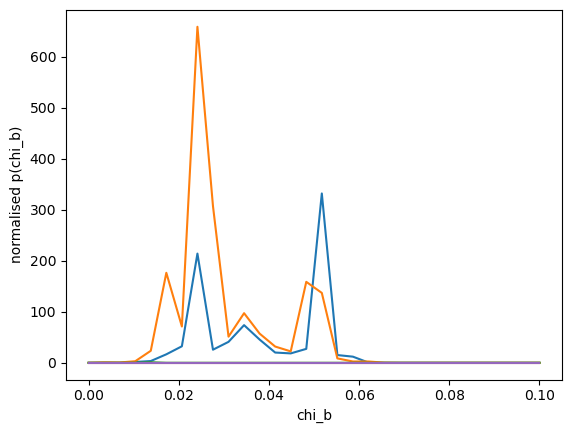

In [15]:
for seed in range(5):
    plt.plot(np.linspace(0,0.1,30), np.exp(prob_10000Nsamps[seed,:])/np.max(np.exp(prob[seed,:])))
    plt.xlabel('chi_b')
    plt.ylabel('normalised p(chi_b)')

In [48]:
#checking lnlike of flow varying chi_eff
prob = []
for i, chieff in enumerate(tqdm(np.linspace(0,1.,1000))):
    x = [0.06,4.8,0.8,0.05,0.01,0.05]
    obsdata = np.array([[[30.,0.8,chieff,0.2]]])
    prob.append(lnlike_cont(x, obsdata, flow, submodels_dict, channels, None, None))

100%|█████████▉| 998/1000 [00:41<00:00, 24.23it/s]/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/testing_notebooks/../../AMAZE_model_selection/populations/Flowsclass_dev.py:565: RuntimeWarning: divide by zero encountered in arctanh
  mapped_data[:,:,2]= np.arctanh(data[:,:,2])
100%|██████████| 1000/1000 [00:41<00:00, 23.90it/s]

nans!
nans!
nans!
nans!
nans!


/tmp/ipykernel_703256/947485168.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.linspace(0,.9,900), np.log10(np.exp(prob))[:900])


Text(0.5, 1.0, 'lambda=[0.06, 4.8, 0.8, 0.05, 0.01, 0.05]')

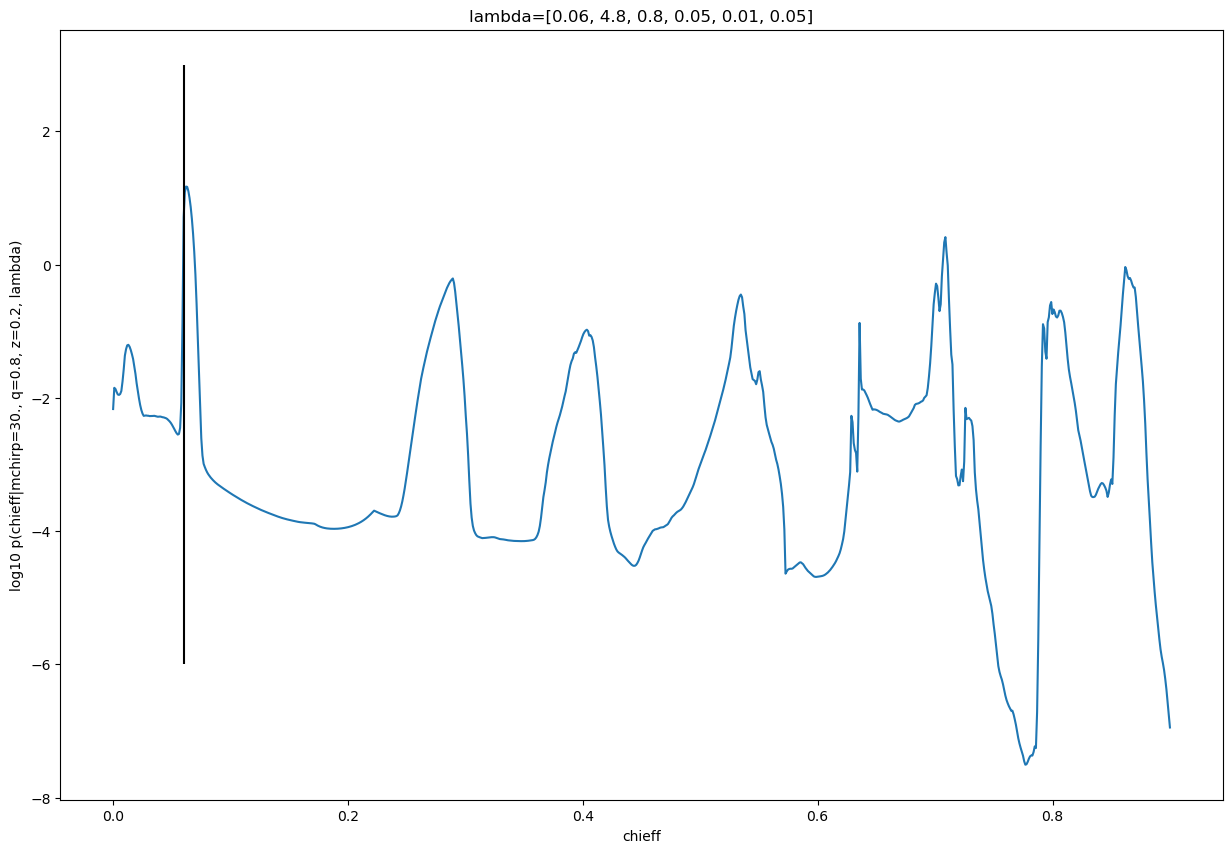

In [51]:
plt.plot(np.linspace(0,.9,900), np.log10(np.exp(prob))[:900])
plt.vlines(0.06,-6,3, color='black')
plt.xlabel('chieff')
plt.ylabel('log10 p(chieff|mchirp=30., q=0.8, z=0.2, lambda)')
plt.title(f'lambda={x}')

 12%|█▏        | 12/100 [00:00<00:00, 115.05it/s]

nans!


100%|██████████| 100/100 [00:00<00:00, 112.52it/s]


nans!


 16%|█▌        | 16/100 [00:00<00:00, 154.16it/s]

...

nans!


 14%|█▍        | 14/100 [00:00<00:00, 131.01it/s]

nans!


100%|██████████| 100/100 [00:00<00:00, 128.83it/s]

nans!


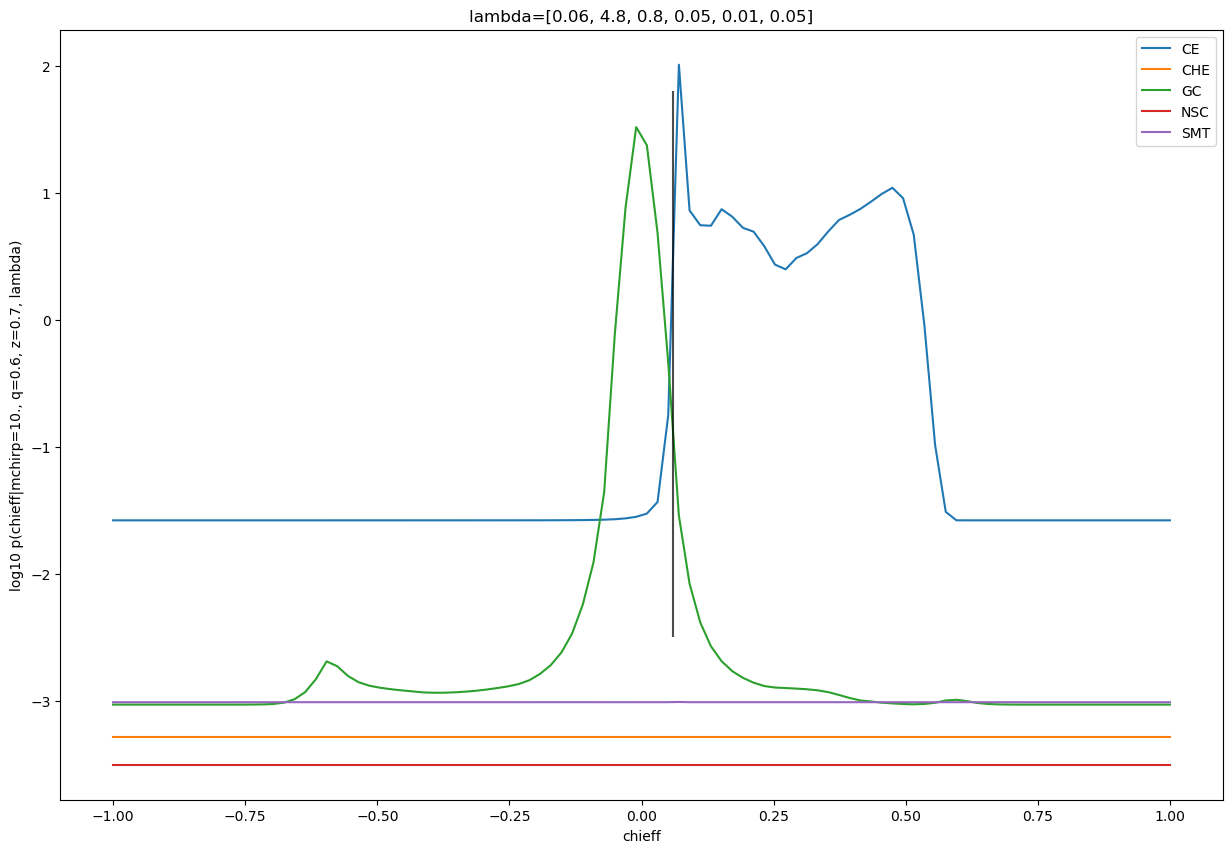

In [58]:
#checking lnlike of flow varying chi_eff and varying channels
for chnl in channels:
    prob = []
    for i, chieff in enumerate(tqdm(np.linspace(-1,1.,100))):
        x = [0.06,4.8,0.8,0.05,0.01,0.05]
        obsdata = np.array([[[10.,0.6,chieff,0.7]]])
        prob.append(lnlike_cont(x, obsdata, flow, submodels_dict, [chnl], None, smallest_N))
    plt.plot(np.linspace(-1,1.,100), np.log10(np.exp(prob)), label=chnl)

plt.vlines(0.06,-2.5,1.8, color='black', alpha=0.7)
plt.xlabel('chieff')
plt.ylabel('log10 p(chieff|mchirp=10., q=0.6, z=0.7, lambda)')
plt.title(f'lambda={x}')
plt.legend()

Text(0.5, 1.0, 'lambda=[0.06, 4.8, 0.8, 0.05, 0.01, 0.05]')

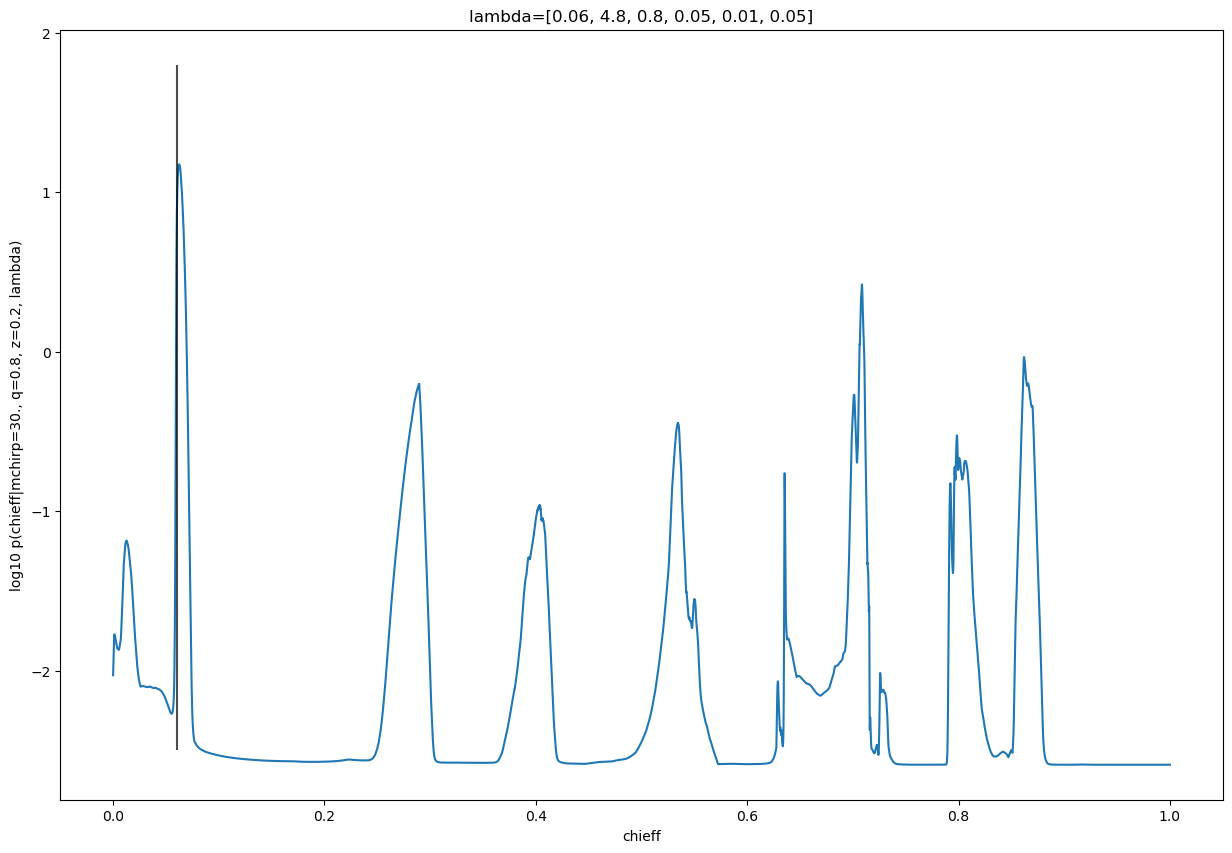

In [43]:
plt.rcParams["figure.figsize"] = (15,10)
plt.plot(np.linspace(0,1.,20000), np.log10(np.exp(prob)))
plt.vlines(0.06,-2.5,1.8, color='black', alpha=0.7)
plt.xlabel('chieff')
plt.ylabel('log10 p(chieff|mchirp=30., q=0.8, z=0.2, lambda)')
plt.title(f'lambda={x}')